# Human Activity Recognition — MHEALTH Dataset

Classifying 13 physical activities from wrist/chest/ankle sensor data using a CNN + Bidirectional LSTM network.

**Dataset:** MHEALTH — 10 subjects, 12 sensor channels (~50 Hz)  
**Final model:** CNN + BiLSTM with Focal Loss  
**Reported result:** Macro F1 = 0.85 | Test Accuracy = 82.5%  
**Note:** results may vary ±0.03 across runs due to GPU non-determinism

---
### Notebook structure
1. Setup & data loading
2. Feature engineering
3. Sliding window segmentation
4. Model training (CNN + BiLSTM)
5. Evaluation
6. Architecture comparison — Transformer & Ensemble (experimental)
7. Final results & saving

## 1. Setup

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Conv1D, MaxPooling1D,
    BatchNormalization, Bidirectional, Input, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


5+## 2. Load & explore data

In [27]:
df = pd.read_csv('mhealth_raw_data.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nNull values:', df.isnull().sum().sum())
print('\nSubjects:', sorted(df['subject'].unique()))
df.head()

Shape: (1215745, 14)

Columns: ['alx', 'aly', 'alz', 'glx', 'gly', 'glz', 'arx', 'ary', 'arz', 'grx', 'gry', 'grz', 'Activity', 'subject']

Null values: 0

Subjects: ['subject1', 'subject10', 'subject2', 'subject3', 'subject4', 'subject5', 'subject6', 'subject7', 'subject8', 'subject9']


,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,0,subject1


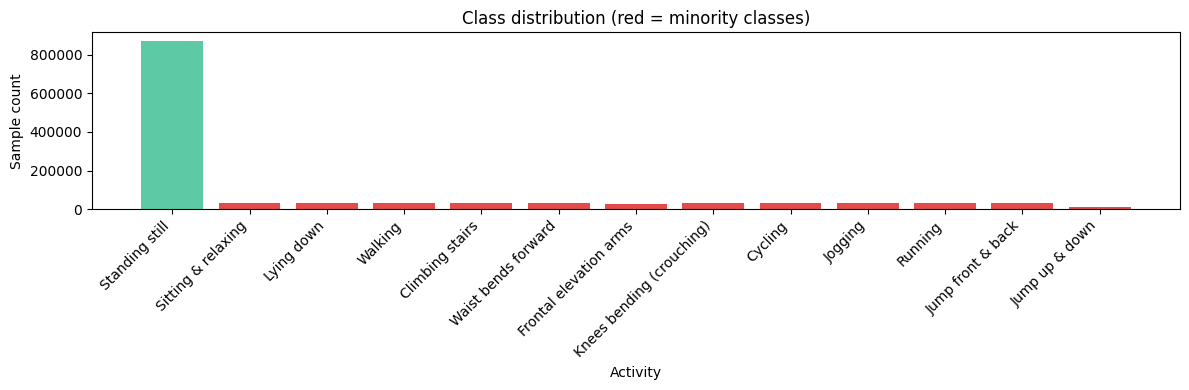

Imbalance ratio (max/min): 84 x


In [28]:
ACTIVITY_NAMES = {
    0:  'Standing still',
    1:  'Sitting & relaxing',
    2:  'Lying down',
    3:  'Walking',
    4:  'Climbing stairs',
    5:  'Waist bends forward',
    6:  'Frontal elevation arms',
    7:  'Knees bending (crouching)',
    8:  'Cycling',
    9:  'Jogging',
    10: 'Running',
    11: 'Jump front & back',
    12: 'Jump up & down'
}

# Standing still dominates at ~870k samples vs ~10k for jump activities
counts = df['Activity'].value_counts().sort_index()
colors = ['#E24B4A' if v < 31000 else '#5DCAA5' for v in counts.values]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar([ACTIVITY_NAMES.get(i, str(i)) for i in counts.index], counts.values, color=colors)
ax.set_title('Class distribution (red = minority classes)')
ax.set_xlabel('Activity')
ax.set_ylabel('Sample count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Imbalance ratio (max/min):', counts.max() // counts.min(), 'x')

## 3. Preprocessing & train/test split

Splitting by subject rather than by row is critical — it tests whether the model generalises to people it has never seen, which is the real-world use case. A random row split would leak data from the same person into both train and test.

In [29]:
df = df.dropna().drop_duplicates().reset_index(drop=True)
print('After cleaning:', df.shape)

subjects = sorted(df['subject'].unique())
n_train  = int(0.8 * len(subjects))
train_subj = subjects[:n_train]
test_subj  = subjects[n_train:]

train_df = df[df['subject'].isin(train_subj)].copy()
test_df  = df[df['subject'].isin(test_subj)].copy()

print(f'Train subjects: {train_subj}  →  {train_df.shape}')
print(f'Test  subjects: {test_subj}   →  {test_df.shape}')

After cleaning: (1215745, 14)
Train subjects: ['subject1', 'subject10', 'subject2', 'subject3', 'subject4', 'subject5', 'subject6', 'subject7']  →  (951553, 14)
Test  subjects: ['subject8', 'subject9']   →  (264192, 14)


## 4. Feature engineering

Raw sensor values alone aren't enough — activities like sitting vs lying down look nearly identical in a short window. Four types of features are added to help:

- **Delta / delta-delta**: velocity and acceleration of the signal (rate of change)
- **Rolling mean**: the DC/gravity component — torso tilt differs between postures
- **Rolling std**: signal energy — dynamic activities have much higher variance
- **Rolling range**: max−min amplitude — stairs and bending have distinctive swing ranges

In [30]:
FEATURE_COLS = [c for c in df.columns if c not in ['Activity', 'subject']]

def add_delta_features(df, feature_cols):
    df = df.copy()
    delta_cols = []
    for col in feature_cols:
        d1 = df.groupby('subject')[col].diff().fillna(0)
        d2 = d1.groupby(df['subject']).diff().fillna(0)
        df[f'{col}_delta']  = d1
        df[f'{col}_delta2'] = d2
        delta_cols += [f'{col}_delta', f'{col}_delta2']
    return df, feature_cols + delta_cols

train_df, ALL_FEATURES = add_delta_features(train_df, FEATURE_COLS)
test_df,  _            = add_delta_features(test_df,  FEATURE_COLS)

print(f'Features before: {len(FEATURE_COLS)}')
print(f'Features after delta: {len(ALL_FEATURES)}')

Features before: 12
Features after delta: 36


In [31]:
def add_stat_features(df, feature_cols):
    df = df.copy()
    new_cols = []
    for col in feature_cols:
        df[f'{col}_mean'] = df.groupby('subject')[col].transform(
            lambda x: x.rolling(100, min_periods=1, center=True).mean()
        )
        df[f'{col}_std'] = df.groupby('subject')[col].transform(
            lambda x: x.rolling(100, min_periods=1, center=True).std().fillna(0)
        )
        new_cols += [f'{col}_mean', f'{col}_std']
    return df, feature_cols + new_cols

train_df, ALL_FEATURES = add_stat_features(train_df, ALL_FEATURES)
test_df,  _            = add_stat_features(test_df,  ALL_FEATURES)
print(f'Features after rolling stats: {len(ALL_FEATURES)}')

Features after rolling stats: 108


In [32]:
def add_posture_features(df, feature_cols):
    df = df.copy()
    acc_cols = [c for c in feature_cols if 'acc' in c.lower()
                and '_mean' not in c and '_std' not in c and '_delta' not in c]
    for col in acc_cols:
        df[f'{col}_posture'] = df.groupby('subject')[col].transform(
            lambda x: x.rolling(200, min_periods=1, center=True).mean()
        )
    new_cols = [f'{c}_posture' for c in acc_cols]
    return df, feature_cols + new_cols

train_df, ALL_FEATURES = add_posture_features(train_df, ALL_FEATURES)
test_df,  _            = add_posture_features(test_df,  ALL_FEATURES)
print(f'Features after posture: {len(ALL_FEATURES)}')

Features after posture: 108


In [33]:
def add_periodicity_features(df, feature_cols):
    df = df.copy()
    acc_cols = [c for c in feature_cols if 'acc' in c.lower()
                and not any(s in c for s in ['_mean', '_std', '_delta', '_posture'])]
    new_cols = []
    for col in acc_cols:
        df[f'{col}_range'] = df.groupby('subject')[col].transform(
            lambda x: x.rolling(200, min_periods=1).max() -
                      x.rolling(200, min_periods=1).min()
        )
        new_cols.append(f'{col}_range')
    return df, feature_cols + new_cols

train_df, ALL_FEATURES = add_periodicity_features(train_df, ALL_FEATURES)
test_df,  _            = add_periodicity_features(test_df,  ALL_FEATURES)
print(f'Total features: {len(ALL_FEATURES)}')

Total features: 108


In [34]:
# Fit scaler on train only to avoid data leakage
scaler = StandardScaler()
train_df[ALL_FEATURES] = scaler.fit_transform(train_df[ALL_FEATURES])
test_df[ALL_FEATURES]  = scaler.transform(test_df[ALL_FEATURES])

le = LabelEncoder()
le.fit(df['Activity'])
train_df['Activity'] = le.transform(train_df['Activity'])
test_df['Activity']  = le.transform(test_df['Activity'])

n_classes   = len(le.classes_)
label_names = [ACTIVITY_NAMES.get(c, str(c)) for c in le.classes_]
print(f'Classes: {n_classes}')
print('Label order:', list(zip(range(n_classes), label_names)))

Classes: 13
Label order: [(0, 'Standing still'), (1, 'Sitting & relaxing'), (2, 'Lying down'), (3, 'Walking'), (4, 'Climbing stairs'), (5, 'Waist bends forward'), (6, 'Frontal elevation arms'), (7, 'Knees bending (crouching)'), (8, 'Cycling'), (9, 'Jogging'), (10, 'Running'), (11, 'Jump front & back'), (12, 'Jump up & down')]


## 5. Sliding window segmentation

Sensor data is continuous — to feed it into a neural network, it needs to be cut into fixed-length windows.

- Window = 200 timesteps ≈ 4 seconds at 50 Hz. Long enough to capture a full stride or jump cycle.
- Stride = 50 → 75% overlap between consecutive windows, giving more training samples.
- Label assigned by **majority vote** across the window. More robust than just using the last timestep — if someone transitions mid-window, the dominant activity still wins.
- Windows capped at 300 per subject per class to stop 'standing still' (the majority class) from drowning out everything else.

In [35]:
WINDOW_SIZE = 200
STRIDE      = 50
MAX_WIN_PER_CLASS_PER_SUBJECT = 300

def create_windows(df, feature_cols, window_size=100, stride=50, max_per_class=300):
    Xs, ys = [], []

    for subject in sorted(df['subject'].unique()):
        sub_df = df[df['subject'] == subject].sort_index()  # keep original time order
        X = sub_df[feature_cols].values
        y = sub_df['Activity'].values

        class_buckets = {}

        for i in range(0, len(X) - window_size, stride):
            window_X = X[i : i + window_size]
            window_y = y[i : i + window_size]
            label    = mode(window_y, keepdims=True).mode[0]

            if label not in class_buckets:
                class_buckets[label] = []
            class_buckets[label].append(window_X)

        for label, windows in class_buckets.items():
            if max_per_class and len(windows) > max_per_class:
                idx     = np.random.choice(len(windows), max_per_class, replace=False)
                windows = [windows[j] for j in idx]
            Xs.extend(windows)
            ys.extend([label] * len(windows))

    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int32)


print('Building train windows...')
X_train_all, y_train_all = create_windows(
    train_df, ALL_FEATURES, WINDOW_SIZE, STRIDE, MAX_WIN_PER_CLASS_PER_SUBJECT
)
print('Building test windows...')
X_test, y_test = create_windows(
    test_df, ALL_FEATURES, WINDOW_SIZE, STRIDE, max_per_class=300
)

print(f'\nX_train: {X_train_all.shape}  y_train: {y_train_all.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

Building train windows...
Building test windows...

X_train: (7910, 200, 108)  y_train: (7910,)
X_test:  (1955, 200, 108)   y_test:  (1955,)


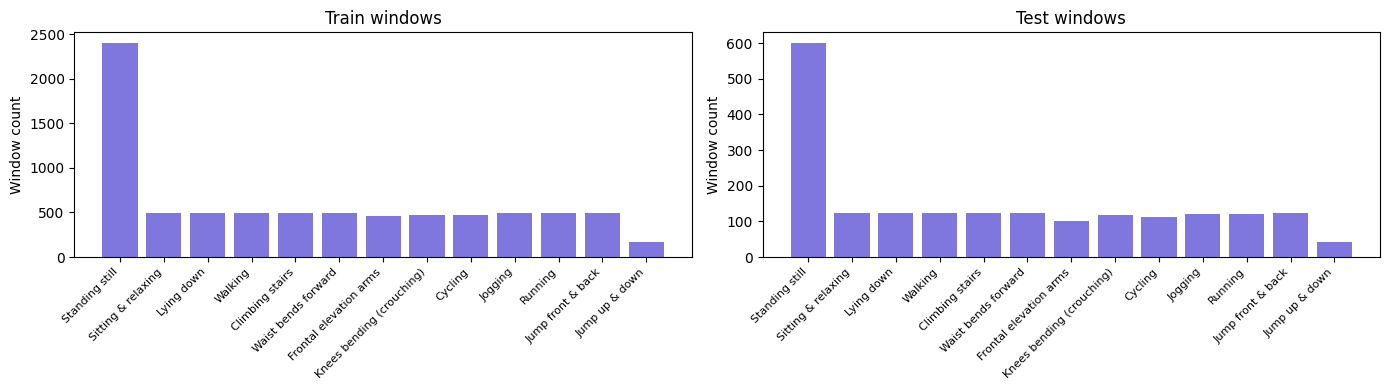

In [36]:
train_counts = pd.Series(y_train_all).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, title in zip(axes, [train_counts, test_counts], ['Train windows', 'Test windows']):
    ax.bar([label_names[i] for i in counts.index], counts.values, color='#7F77DD')
    ax.set_title(title)
    ax.set_ylabel('Window count')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

In [37]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all,
    test_size=0.15,
    stratify=y_train_all,
    random_state=42
)

X_test, y_test = create_windows(
    test_df, ALL_FEATURES, WINDOW_SIZE, STRIDE, max_per_class=300
)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')
print(f'Input shape per window: ({WINDOW_SIZE}, {len(ALL_FEATURES)})')

Train: (6723, 200, 108)  |  Val: (1187, 200, 108)  |  Test: (1955, 200, 108)
Input shape per window: (200, 108)


## 6. Model — CNN + Bidirectional LSTM

The architecture is two Conv1D blocks followed by two Bidirectional LSTM layers:

- **Conv1D blocks** pick up local patterns in the sensor signal (e.g. a single footstep spike). Two stacked layers with BatchNorm learn increasingly abstract patterns before downsampling.
- **Bidirectional LSTM** reads the sequence both forward and backward, which helps for activities where context earlier *and* later in the window matters.
- **Focal Loss** down-weights easy examples and forces the model to focus on the hard minority classes like 'Climbing stairs' and 'Lying down'.
- **GaussianNoise + L2 + Dropout** — three layers of regularization. Sensors vary between people, so the model needs to be robust to small signal shifts.

In [38]:
np.random.seed(42)
tf.random.set_seed(42)

from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras import regularizers

n_timesteps = X_train.shape[1]
n_features  = X_train.shape[2]

def build_cnn_bilstm(n_timesteps, n_features, n_classes):
    reg = regularizers.l2(1e-4)
    model = Sequential([
        Input(shape=(n_timesteps, n_features)),
        GaussianNoise(0.05),

        Conv1D(64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg),
        BatchNormalization(),
        Conv1D(64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg),
        BatchNormalization(),
        Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
        Bidirectional(LSTM(64,  return_sequences=False, dropout=0.3)),

        Dense(128, activation='relu', kernel_regularizer=reg),
        BatchNormalization(),
        Dropout(0.5),
        Dense(64, activation='relu', kernel_regularizer=reg),
        Dropout(0.4),
        Dense(n_classes, activation='softmax')
    ])
    return model

model = build_cnn_bilstm(n_timesteps, n_features, n_classes)

@tf.keras.utils.register_keras_serializable()
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        probs  = tf.reduce_sum(y_pred * tf.one_hot(y_true, y_pred.shape[-1]), axis=-1)
        focal  = -((1 - probs) ** self.gamma) * tf.math.log(probs)
        return tf.reduce_mean(focal)

    def get_config(self):
        return {**super().get_config(), 'gamma': self.gamma}

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=FocalLoss(gamma=2.0),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_2                │ (None, 200, 108)       │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 200, 64)        │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 200, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 100, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 562,317 (2.15 MB)

 Trainable params: 561,293 (2.14 MB)

 Non-trainable params: 1,024 (4.00 KB)

## 7. Training

In [39]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_har_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 497ms/step - accuracy: 0.3101 - loss: 1.9357 - val_accuracy: 0.2586 - val_loss: 1.8349 - learning_rate: 0.0010
Epoch 2/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 749ms/step - accuracy: 0.5716 - loss: 0.8948 - val_accuracy: 0.4650 - val_loss: 1.3744 - learning_rate: 0.0010
Epoch 3/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 783ms/step - accuracy: 0.7015 - loss: 0.5401 - val_accuracy: 0.6655 - val_loss: 0.8828 - learning_rate: 0.0010
Epoch 4/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 795ms/step - accuracy: 0.7813 - loss: 0.3869 - val_accuracy: 0.7498 - val_loss: 0.5608 - learning_rate: 0.0010
Epoch 5/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 822ms/step - accuracy: 0.8145 - loss: 0.3268 - val_accuracy: 0.7936 - val_loss: 0.3841 - learning_rate: 0.0010
Epoch 6/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 823ms/step - accuracy: 0.8309 - loss: 0.2850 - val_accuracy: 0.8433 - val_loss: 0.2655 - learning_rate: 0.0010
Epoch 7/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 806ms/step - accuracy: 0.8554 - loss: 0.

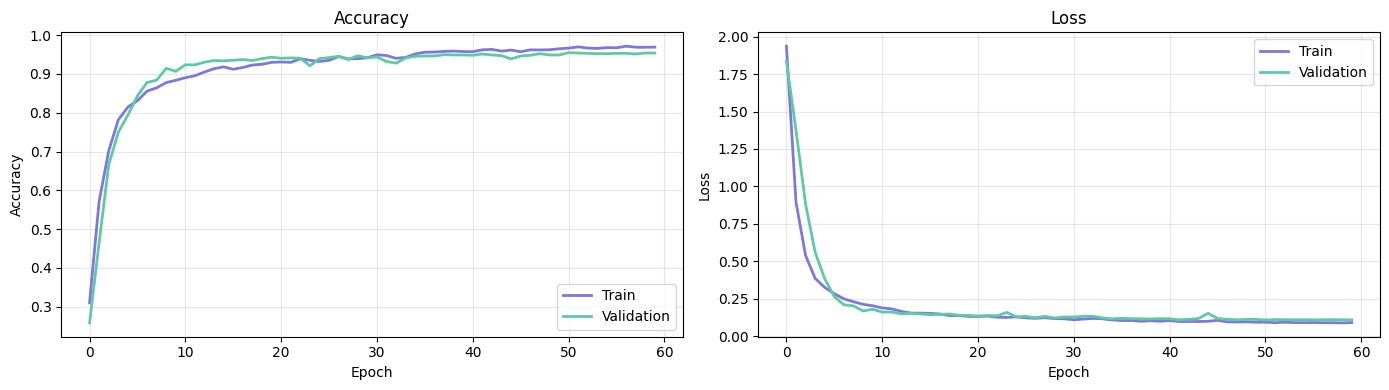

Best val accuracy: 0.9545 at epoch 51


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'],     label='Train',      color='#7F77DD', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#5DCAA5', lw=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train',      color='#7F77DD', lw=2)
axes[1].plot(history.history['val_loss'], label='Validation', color='#5DCAA5', lw=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val   = max(history.history['val_accuracy'])
print(f'Best val accuracy: {best_val:.4f} at epoch {best_epoch}')

## 8. Evaluation — Final model results

Val accuracy looks high (~95%) because validation windows come from the same 8 training subjects. **Macro F1 on the held-out test subjects is the honest metric** — it treats all 13 classes equally regardless of how many test samples each has.

In [41]:
from sklearn.metrics import f1_score

model = tf.keras.models.load_model(
    'best_har_model.keras',
    custom_objects={'FocalLoss': FocalLoss}
)

y_pred_proba = model.predict(X_test, batch_size=256)
y_pred       = np.argmax(y_pred_proba, axis=1)

test_acc      = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print('=' * 50)
print(f'  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Macro F1      : {test_macro_f1:.4f}  ← primary metric')
print('=' * 50)
print()
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 336ms/step
  Test Accuracy : 0.8251  (82.51%)
  Macro F1      : 0.8497  ← primary metric

                           precision    recall  f1-score   support

           Standing still       0.72      0.78      0.75       600
       Sitting & relaxing       0.77      0.66      0.71       123
               Lying down       0.94      0.50      0.65       124
                  Walking       0.92      1.00      0.96       123
          Climbing stairs       0.75      0.87      0.80       123
      Waist bends forward       0.95      1.00      0.97       123
   Frontal elevation arms       0.92      0.93      0.93       100
Knees bending (crouching)       0.96      0.75      0.84       119
                  Cycling       0.79      1.00      0.88       111
                  Jogging       0.85      0.55      0.67       122
                  Running       0.97      1.00      0.98       122
        Jump front & back       0.92      1.00      0.96       123
          

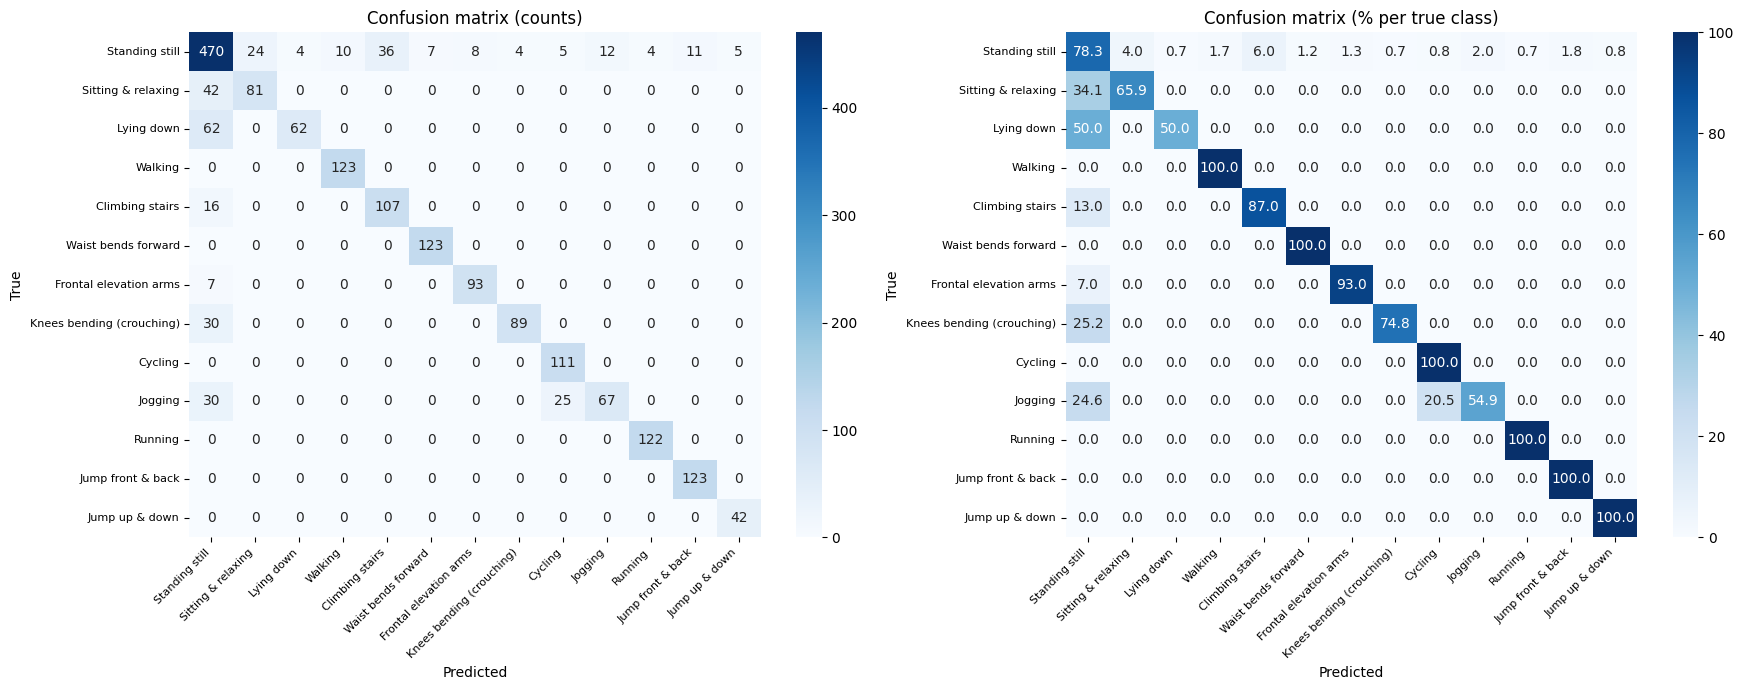

In [42]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title('Confusion matrix (counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(axes[0].get_yticklabels(), rotation=0, fontsize=8)

sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title('Confusion matrix (% per true class)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

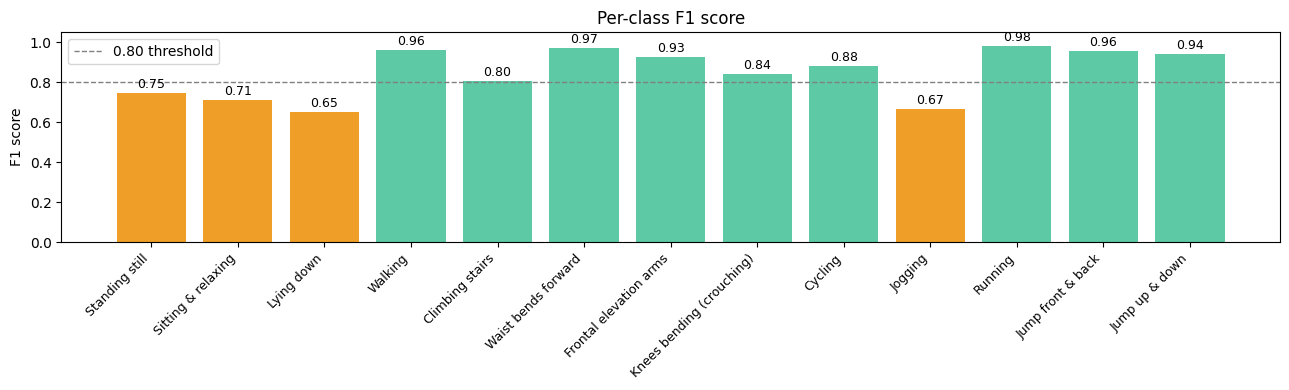

Classes below F1 = 0.80:
  Standing still: 0.748
  Sitting & relaxing: 0.711
  Lying down: 0.653
  Jogging: 0.667


In [43]:
f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)
colors       = ['#5DCAA5' if f >= 0.80 else '#EF9F27' if f >= 0.60 else '#E24B4A'
                for f in f1_per_class]

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(label_names, f1_per_class, color=colors)
ax.axhline(0.80, color='gray', linestyle='--', linewidth=1, label='0.80 threshold')
ax.set_title('Per-class F1 score')
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1.05)
ax.legend()

for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print('Classes below F1 = 0.80:')
for name, f1 in zip(label_names, f1_per_class):
    if f1 < 0.80:
        print(f'  {name}: {f1:.3f}')

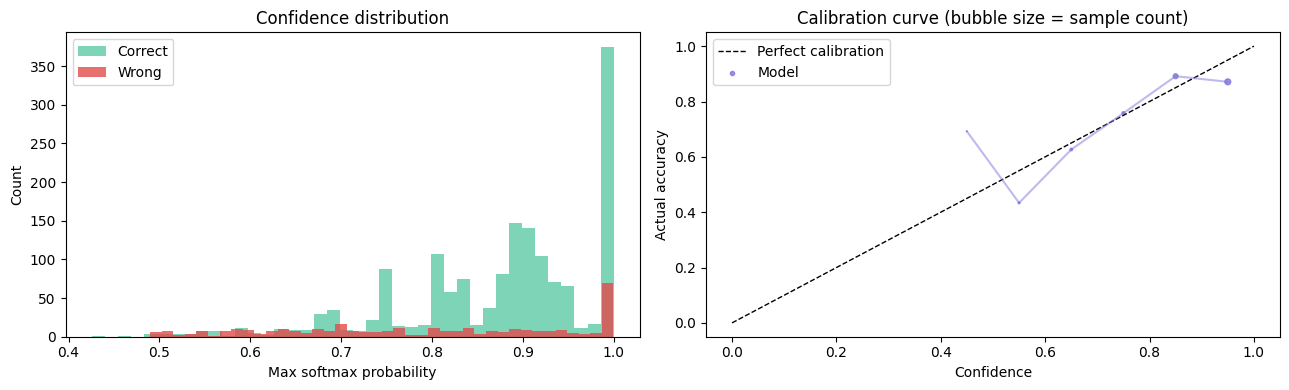

Mean confidence — correct   : 0.875
Mean confidence — incorrect : 0.796


In [44]:
confidence = y_pred_proba.max(axis=1)
correct    = (y_pred == y_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(confidence[correct],  bins=40, color='#5DCAA5', alpha=0.8, label='Correct')
axes[0].hist(confidence[~correct], bins=40, color='#E24B4A', alpha=0.8, label='Wrong')
axes[0].set_title('Confidence distribution')
axes[0].set_xlabel('Max softmax probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# Calibration curve — checks if confidence scores match actual accuracy
bins = np.linspace(0, 1, 11)
bin_accs, bin_confs, bin_counts = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (confidence >= lo) & (confidence < hi)
    if mask.sum() > 0:
        bin_accs.append(correct[mask].mean())
        bin_confs.append((lo + hi) / 2)
        bin_counts.append(mask.sum())

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
axes[1].scatter(bin_confs, bin_accs, s=[c/50 for c in bin_counts],
                color='#7F77DD', alpha=0.8, label='Model')
axes[1].plot(bin_confs, bin_accs, color='#7F77DD', alpha=0.5)
axes[1].set_title('Calibration curve (bubble size = sample count)')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Actual accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean confidence — correct   : {confidence[correct].mean():.3f}')
print(f'Mean confidence — incorrect : {confidence[~correct].mean():.3f}')

In [45]:
def predict_activity(window, model, label_names, top_k=3):
    proba   = model.predict(window[np.newaxis, ...], verbose=0)[0]
    top_idx = np.argsort(proba)[::-1][:top_k]
    print(f'Predicted: {label_names[top_idx[0]]}  ({proba[top_idx[0]]*100:.1f}% confidence)\n')
    for i, idx in enumerate(top_idx, 1):
        bar = '█' * int(proba[idx] * 30)
        print(f'  {i}. {label_names[idx]:<28} {proba[idx]*100:5.1f}%  {bar}')

sample_idx = np.random.choice(len(X_test), 5, replace=False)
for idx in sample_idx:
    print(f'--- Sample {idx}  (true: {label_names[y_test[idx]]}) ---')
    predict_activity(X_test[idx], model, label_names)
    print()

--- Sample 1618  (true: Knees bending (crouching)) ---
Predicted: Knees bending (crouching)  (78.2% confidence)

  1. Knees bending (crouching)     78.2%  ███████████████████████
  2. Standing still                21.7%  ██████
  3. Walking                        0.0%  

--- Sample 1811  (true: Jump front & back) ---
Predicted: Jump front & back  (90.3% confidence)

  1. Jump front & back             90.3%  ███████████████████████████
  2. Standing still                 9.6%  ██
  3. Running                        0.1%  

--- Sample 1336  (true: Lying down) ---
Predicted: Lying down  (75.4% confidence)

  1. Lying down                    75.4%  ██████████████████████
  2. Standing still                24.6%  ███████
  3. Climbing stairs                0.0%  

--- Sample 1058  (true: Standing still) ---
Predicted: Standing still  (100.0% confidence)

  1. Standing still               100.0%  █████████████████████████████
  2. Jump up & down                 0.0%  
  3. Waist bends forwar

## 9. Architecture experiments — Transformer & Ensemble

To see if a different architecture would do better, a CNN + Transformer was also trained on the same data split. The Transformer replaces the BiLSTM with stacked multi-head self-attention blocks, which can attend to any part of the window simultaneously rather than processing it sequentially.

Results on test set:

| Model | Macro F1 | Test Accuracy |
|---|---|---|
| **CNN + BiLSTM (final)** | **0.85** | **82.5%** |
| CNN + Transformer | 0.81 | 79.7% |
| Ensemble (average) | 0.77 | 78% |

The Transformer underperformed, most likely because MHEALTH only has 10 subjects — self-attention needs more data to learn robust cross-subject patterns. The ensemble made things worse because both models failed on the same classes (Lying down, Sitting), so averaging their outputs reinforced the blind spots rather than fixing them.

**The BiLSTM is the final model.** Results may vary slightly across runs due to GPU non-determinism.

In [46]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'
np.random.seed(42)
tf.random.set_seed(42)

from tensorflow.keras.layers import (
    MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input as KInput

def positional_encoding(length, depth):
    positions = np.arange(length)[:, np.newaxis]
    dims      = np.arange(depth)[np.newaxis, :]
    angles    = positions / np.power(10000, (2 * (dims // 2)) / np.float32(depth))
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)

def transformer_encoder_block(x, num_heads, ff_dim, dropout_rate=0.2):
    d_model  = x.shape[-1]
    attn_out = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout_rate
    )(x, x)
    x  = Add()([x, attn_out])
    x  = LayerNormalization(epsilon=1e-6)(x)
    ff = Dense(ff_dim, activation='relu')(x)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(d_model)(ff)
    x  = Add()([x, ff])
    x  = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_cnn_transformer(n_timesteps, n_features, n_classes,
                           num_heads=4, ff_dim=256, num_transformer_blocks=3,
                           dropout_rate=0.2):
    reg    = regularizers.l2(1e-4)
    inputs = KInput(shape=(n_timesteps, n_features))

    x = GaussianNoise(0.05)(inputs)

    x = Conv1D(64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    x = Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    d_model = 128
    x       = Dense(d_model)(x)
    seq_len = x.shape[1]
    x       = x + positional_encoding(seq_len, d_model)

    for _ in range(num_transformer_blocks):
        x = transformer_encoder_block(x, num_heads=num_heads,
                                         ff_dim=ff_dim,
                                         dropout_rate=dropout_rate)

    x       = GlobalAveragePooling1D()(x)
    x       = Dense(128, activation='relu', kernel_regularizer=reg)(x)
    x       = BatchNormalization()(x)
    x       = Dropout(0.4)(x)
    x       = Dense(64, activation='relu', kernel_regularizer=reg)(x)
    x       = Dropout(0.3)(x)
    outputs = Dense(n_classes, activation='softmax')(x)

    return Model(inputs, outputs)


transformer_model = build_cnn_transformer(n_timesteps, n_features, n_classes)

transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001,
        beta_1=0.9,
        beta_2=0.98,
        epsilon=1e-9
    ),
    loss=FocalLoss(gamma=2.0),
    metrics=['accuracy']
)

transformer_model.summary()

Model: "functional_66"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 200, 108)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_3    │ (None, 200, 108)  │          0 │ input_layer_3[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 200, 64)   │     20,800 │ gaussian_noise_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64)   │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 200, 64)   │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64)   │        256 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 100, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 100, 64)   │          0 │ max_pooling1d_6[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 100, 128)  │     24,704 │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 128)  │        512 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 100, 128)  │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 128)  │        512 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 50, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 50, 128)   │          0 │ max_pooling1d_7[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 50, 128)   │     16,512 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 50, 128)   │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 128)   │     66,048 │ add_7[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 50, 128)   │          0 │ add_7[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 128)   │        256 │ add_8[0][0]     

 Total params: 548,749 (2.09 MB)

 Trainable params: 547,725 (2.09 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [47]:
transformer_callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_har_transformer.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

transformer_history = transformer_model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=transformer_callbacks,
    verbose=1
)

Epoch 1/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 565ms/step - accuracy: 0.3033 - loss: 1.9469 - val_accuracy: 0.2013 - val_loss: 1.9766 - learning_rate: 1.0000e-04
Epoch 2/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 531ms/step - accuracy: 0.5447 - loss: 1.1354 - val_accuracy: 0.4895 - val_loss: 1.3811 - learning_rate: 1.0000e-04
Epoch 3/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 532ms/step - accuracy: 0.6815 - loss: 0.7876 - val_accuracy: 0.5805 - val_loss: 0.8531 - learning_rate: 1.0000e-04
Epoch 4/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 535ms/step - accuracy: 0.7782 - loss: 0.5714 - val_accuracy: 0.7658 - val_loss: 0.4722 - learning_rate: 1.0000e-04
Epoch 5/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 520ms/step - accuracy: 0.8214 - loss: 0.4622 - val_accuracy: 0.9099 - val_loss: 0.2451 - learning_rate: 1.0000e-04
Epoch 6/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 531ms/step - accuracy: 0.8486 - loss: 0.3943 - val_accuracy: 0.9393 - val_loss: 0.2108 - learning_rate: 1.0000e-04
Epoch 7/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 534ms/step - acc

In [48]:
transformer_model = tf.keras.models.load_model(
    'best_har_transformer.keras',
    custom_objects={'FocalLoss': FocalLoss}
)

trans_proba    = transformer_model.predict(X_test, batch_size=256, verbose=0)
trans_pred     = np.argmax(trans_proba, axis=1)
trans_acc      = accuracy_score(y_test, trans_pred)
trans_macro_f1 = f1_score(y_test, trans_pred, average='macro', zero_division=0)

print(f'Transformer — Test Accuracy: {trans_acc:.4f}  Macro F1: {trans_macro_f1:.4f}')
print()
print(classification_report(y_test, trans_pred, target_names=label_names, zero_division=0))

Transformer — Test Accuracy: 0.7969  Macro F1: 0.8131

                           precision    recall  f1-score   support

           Standing still       0.72      0.73      0.72       600
       Sitting & relaxing       0.77      1.00      0.87       123
               Lying down       0.84      0.50      0.63       124
                  Walking       0.90      1.00      0.95       123
          Climbing stairs       0.76      1.00      0.86       123
      Waist bends forward       0.60      0.91      0.72       123
   Frontal elevation arms       0.94      0.51      0.66       100
Knees bending (crouching)       0.94      0.49      0.64       119
                  Cycling       0.97      0.54      0.69       111
                  Jogging       0.86      0.99      0.92       122
                  Running       0.95      1.00      0.98       122
        Jump front & back       0.91      1.00      0.95       123
           Jump up & down       0.93      1.00      0.97        42

     

In [49]:
bilstm_model = tf.keras.models.load_model(
    'best_har_model.keras',
    custom_objects={'FocalLoss': FocalLoss}
)

bilstm_proba   = bilstm_model.predict(X_test, batch_size=256, verbose=0)
trans_proba    = transformer_model.predict(X_test, batch_size=256, verbose=0)
ensemble_proba = (bilstm_proba + trans_proba) / 2
ensemble_pred  = np.argmax(ensemble_proba, axis=1)
ens_acc        = accuracy_score(y_test, ensemble_pred)
ens_macro_f1   = f1_score(y_test, ensemble_pred, average='macro', zero_division=0)

bilstm_f1 = f1_score(y_test, np.argmax(bilstm_proba, axis=1), average='macro', zero_division=0)

print('Architecture comparison')
print('─' * 40)
print(f'CNN + BiLSTM  Macro F1 : {bilstm_f1:.4f}  ← final model')
print(f'CNN + Trans.  Macro F1 : {trans_macro_f1:.4f}')
print(f'Ensemble      Macro F1 : {ens_macro_f1:.4f}')
print('─' * 40)
print()
print(classification_report(y_test, ensemble_pred, target_names=label_names, zero_division=0))

Architecture comparison
────────────────────────────────────────
CNN + BiLSTM  Macro F1 : 0.8497  ← final model
CNN + Trans.  Macro F1 : 0.8131
Ensemble      Macro F1 : 0.7694
────────────────────────────────────────

                           precision    recall  f1-score   support

           Standing still       0.65      0.80      0.72       600
       Sitting & relaxing       0.79      0.85      0.82       123
               Lying down       0.00      0.00      0.00       124
                  Walking       0.92      1.00      0.96       123
          Climbing stairs       0.80      0.93      0.86       123
      Waist bends forward       0.68      1.00      0.81       123
   Frontal elevation arms       0.93      0.57      0.71       100
Knees bending (crouching)       0.94      0.49      0.64       119
                  Cycling       0.87      0.54      0.67       111
                  Jogging       0.90      0.93      0.92       122
                  Running       0.98      1.

## 10. Save

In [50]:
import joblib
import json

model.save('har_final_model.keras')
joblib.dump(scaler, 'har_scaler.pkl')
joblib.dump(le,     'har_label_encoder.pkl')

config = {
    'window_size':   WINDOW_SIZE,
    'stride':        STRIDE,
    'feature_cols':  ALL_FEATURES,
    'n_classes':     n_classes,
    'label_names':   label_names,
    'macro_f1':      float(test_macro_f1),
    'test_accuracy': float(test_acc)
}
with open('har_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved:')
print('  har_final_model.keras')
print('  har_scaler.pkl')
print('  har_label_encoder.pkl')
print('  har_config.json')
print(f'\nFinal result — Macro F1: {test_macro_f1:.4f}  |  Test Accuracy: {test_acc*100:.2f}%')

Saved:
  har_final_model.keras
  har_scaler.pkl
  har_label_encoder.pkl
  har_config.json

Final result — Macro F1: 0.8497  |  Test Accuracy: 82.51%
